In [1]:
import qiskit

In [2]:
qiskit.__version__

'2.3.1'

# Hello World Example - 2 Qubits : Bell State

### Step 1: Map the problem to circuits and operators

In [7]:
from qiskit import QuantumCircuit

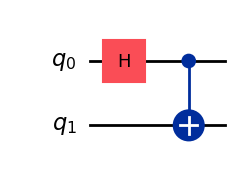

In [8]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

qc.draw(output="mpl")

In [9]:
from qiskit.quantum_info import Pauli

ZZ = Pauli("ZZ")
ZI = Pauli("ZI")
IZ = Pauli("IZ")
XX = Pauli("XX")
XI = Pauli("XI")
IX = Pauli("IX")

observable = [ZZ, ZI, IZ, XX, XI, IX]

### Step 2: Execute on the backend

In [10]:
from qiskit_aer.primitives import Estimator

estimator = Estimator()

job = estimator.run([qc] * len(observable), observable)

job.result()

EstimatorResult(values=array([1.        , 0.01953125, 0.01953125, 1.        , 0.03710938,
       0.03710938]), metadata=[{'shots': 1024, 'variance': 0.0, 'simulator_metadata': [{'time_taken': 0.001308917, 'num_bind_params': 1, 'parallel_state_update': 4, 'parallel_shots': 1, 'required_memory_mb': 0, 'input_qubit_map': [[1, 1], [0, 0]], 'method': 'stabilizer', 'device': 'CPU', 'num_qubits': 2, 'sample_measure_time': 0.000285334, 'active_input_qubits': [0, 1], 'num_clbits': 2, 'remapped_qubits': False, 'runtime_parameter_bind': False, 'max_memory_mb': 7850, 'noise': 'ideal', 'measure_sampling': True, 'batched_shots_optimization': False, 'fusion': {'enabled': False}}]}, {'shots': 1024, 'variance': 0.9996185302734375, 'simulator_metadata': [{'time_taken': 0.001308917, 'num_bind_params': 1, 'parallel_state_update': 4, 'parallel_shots': 1, 'required_memory_mb': 0, 'input_qubit_map': [[1, 1], [0, 0]], 'method': 'stabilizer', 'device': 'CPU', 'num_qubits': 2, 'sample_measure_time': 0.000285334

### Step 3: Post processing and plotting

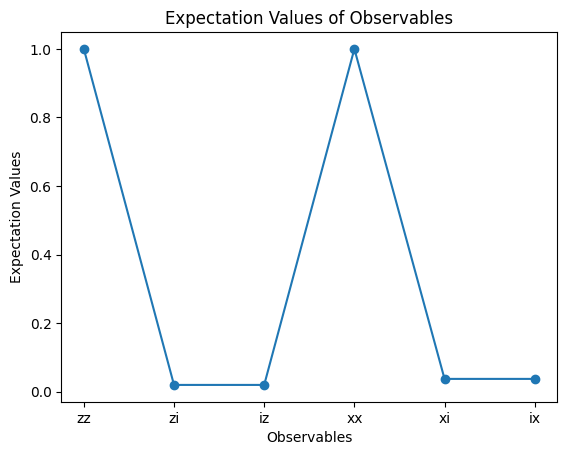

In [11]:
import matplotlib.pyplot as plt

data = ['zz', 'zi', 'iz', 'xx', 'xi', 'ix']
values = job.result().values

plt.plot(data, values, '-o')
plt.xlabel('Observables')
plt.ylabel('Expectation Values')
plt.title('Expectation Values of Observables')

plt.show()